In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import DQN as SB3DQN
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor

from rl.train import train
from rl.evaluate import (
    make_env,
    evaluate_custom_agent,
    evaluate_sb3_model,
    record_custom_rollout,
    record_sb3_rollout,
    find_custom_failure_case,
    find_sb3_failure_case,
)
from rl.visualize import (
    plot_training_curve,
    make_results_table,
    plot_metric_comparison,
    show_side_by_side_gifs,
    print_failure_case,
)

TRAIN_SEEDS = [0, 1, 2]
EVAL_SEEDS = list(range(1000, 1050))

TOTAL_STEPS = 20_000
LEARNING_STARTS = 1_000

ARTIFACTS = Path("artifacts")
ARTIFACTS.mkdir(exist_ok=True)

custom_agents = {}
custom_metrics = {}
custom_rows = []

sb3_models = {}
sb3_rows = []


/Users/tomas/Documents/Cours 2025-2026/Current/RL/Projet/.venv/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [ ]:
for seed in TRAIN_SEEDS:
    agent, metrics = train(seed=seed, run_dir=ARTIFACTS / "custom" / f"seed_{seed}")
    custom_agents[seed] = agent
    custom_metrics[seed] = metrics

    result = evaluate_custom_agent(agent, EVAL_SEEDS)
    custom_rows.append(
        {
            "algo": "custom_dqn",
            "train_seed": seed,
            "mean_return": result["mean_return"],
            "std_return": result["std_return"],
            "mean_length": result["mean_length"],
            "crash_rate": result["crash_rate"],
        }
    )


Using device: mps
step=23, return=16.43, epsilon=1.000
step=51, return=20.09, epsilon=1.000
step=81, return=21.40, epsilon=1.000
step=92, return=8.60, epsilon=1.000
step=116, return=17.98, epsilon=1.000
step=119, return=1.77, epsilon=1.000
step=128, return=7.20, epsilon=1.000
step=135, return=5.76, epsilon=1.000
step=149, return=9.53, epsilon=1.000
step=160, return=8.25, epsilon=1.000
step=167, return=5.75, epsilon=1.000
step=188, return=15.15, epsilon=1.000
step=198, return=7.88, epsilon=1.000
step=221, return=17.66, epsilon=1.000
step=225, return=2.40, epsilon=1.000
step=229, return=2.76, epsilon=1.000
step=241, return=8.68, epsilon=1.000
step=247, return=3.89, epsilon=1.000
step=255, return=5.69, epsilon=1.000
step=273, return=14.29, epsilon=1.000
step=279, return=4.01, epsilon=1.000
step=288, return=7.32, epsilon=1.000
step=315, return=19.77, epsilon=1.000
step=320, return=3.60, epsilon=1.000
step=330, return=8.56, epsilon=1.000
step=339, return=7.75, epsilon=1.000
step=347, return

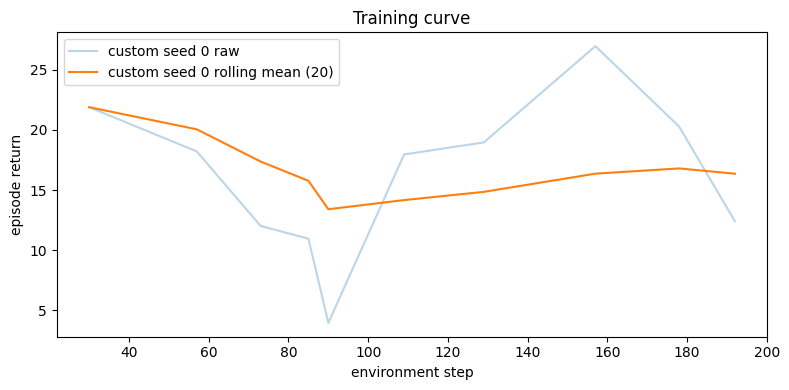

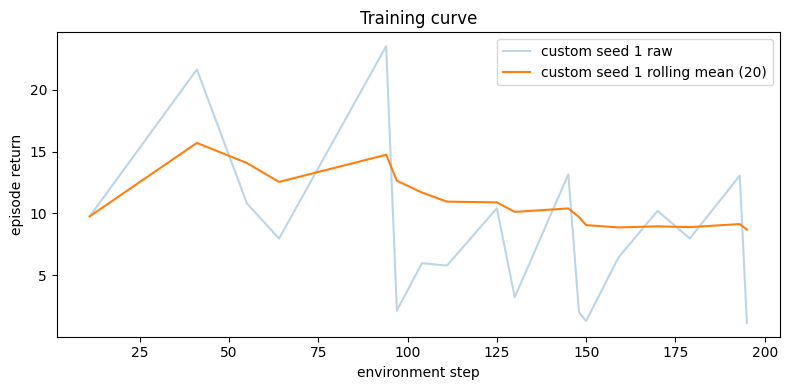

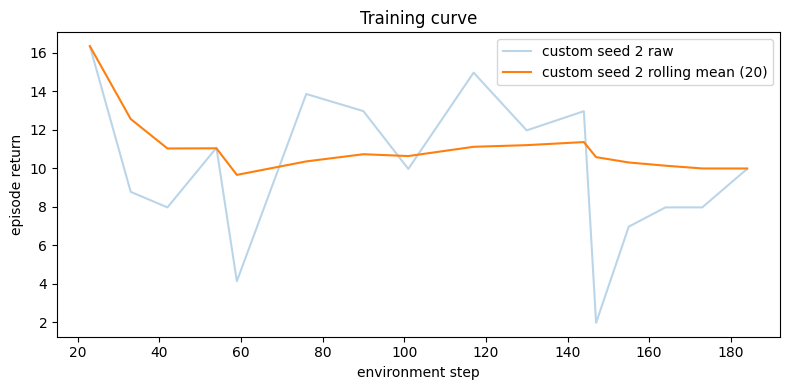

In [ ]:
for seed in TRAIN_SEEDS:
    plot_training_curve(custom_metrics[seed], label=f"custom seed {seed}")


In [ ]:
for seed in TRAIN_SEEDS:
    run_dir = ARTIFACTS / "sb3" / f"seed_{seed}"
    run_dir.mkdir(parents=True, exist_ok=True)

    train_env = Monitor(make_env())
    eval_env = Monitor(make_env())

    train_env.reset(seed=seed)
    eval_env.reset(seed=seed + 10_000)

    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=str(run_dir),
        log_path=str(run_dir),
        eval_freq=1000,
        n_eval_episodes=10,
        deterministic=True,
        render=False,
        verbose=0,
    )

    model = SB3DQN(
        "MlpPolicy",
        train_env,
        seed=seed,
        learning_rate=1e-3,
        buffer_size=10_000,
        learning_starts=LEARNING_STARTS,
        batch_size=32,
        gamma=0.99,
        train_freq=1,
        gradient_steps=1,
        target_update_interval=1000,
        exploration_initial_eps=1.0,
        exploration_final_eps=0.05,
        exploration_fraction=(TOTAL_STEPS - LEARNING_STARTS) / TOTAL_STEPS,
        policy_kwargs=dict(net_arch=[128, 128]),
        verbose=0,
    )

    model.learn(total_timesteps=TOTAL_STEPS, callback=eval_callback)
    model.save(run_dir / "final_model")

    result = evaluate_sb3_model(model, EVAL_SEEDS)
    sb3_models[seed] = model
    sb3_rows.append(
        {
            "algo": "sb3_dqn",
            "train_seed": seed,
            "mean_return": result["mean_return"],
            "std_return": result["std_return"],
            "mean_length": result["mean_length"],
            "crash_rate": result["crash_rate"],
        }
    )

    train_env.close()
    eval_env.close()


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 16       |
|    ep_rew_mean      | 11.8     |
|    exploration_rate | 0.97     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 13       |
|    time_elapsed     | 4        |
|    total_timesteps  | 64       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 12.6     |
|    ep_rew_mean      | 9.35     |
|    exploration_rate | 0.952    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 13       |
|    time_elapsed     | 7        |
|    total_timesteps  | 101      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 12.2     |
|    ep_rew_mean      | 9.26   

/Users/tomas/Documents/Cours 2025-2026/Current/RL/Projet/.venv/lib/python3.11/site-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Eval num_timesteps=1000, episode_reward=20.45 +/- 0.00
Episode length: 30.00 +/- 0.00
----------------------------------
| eval/               |          |
|    mean_ep_length   | 30       |
|    mean_reward      | 20.5     |
| rollout/            |          |
|    exploration_rate | 0.525    |
| time/               |          |
|    total_timesteps  | 1000     |
----------------------------------
New best mean reward!
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 13       |
|    ep_rew_mean      | 9.61     |
|    exploration_rate | 0.506    |
| time/               |          |
|    episodes         | 80       |
|    fps              | 11       |
|    time_elapsed     | 90       |
|    total_timesteps  | 1040     |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.0237   |
|    n_updates        | 39       |
----------------------------------
----------------------------------
| rollout/       

In [ ]:
for seed in TRAIN_SEEDS:
    eval_file = ARTIFACTS / "sb3" / f"seed_{seed}" / "evaluations.npz"
    data = np.load(eval_file)

    timesteps = data["timesteps"]
    results = data["results"]

    plt.figure(figsize=(8, 4))
    plt.plot(timesteps, results.mean(axis=1), label=f"sb3 seed {seed}")
    plt.fill_between(
        timesteps,
        results.mean(axis=1) - results.std(axis=1),
        results.mean(axis=1) + results.std(axis=1),
        alpha=0.2,
    )
    plt.xlabel("environment step")
    plt.ylabel("evaluation return")
    plt.title(f"SB3 evaluation curve - seed {seed}")
    plt.legend()
    plt.show()


In [ ]:
all_rows = custom_rows + sb3_rows
df, summary = make_results_table(all_rows)

display(df)
display(summary)

plot_metric_comparison(df)


In [ ]:
custom_rollout = record_custom_rollout(
    custom_agents[0],
    seed=1234,
    gif_path=ARTIFACTS / "rollouts" / "custom_seed0.gif",
)

sb3_rollout = record_sb3_rollout(
    sb3_models[0],
    seed=1234,
    gif_path=ARTIFACTS / "rollouts" / "sb3_seed0.gif",
)

show_side_by_side_gifs(
    custom_rollout["gif_path"],
    sb3_rollout["gif_path"],
    left_title="Custom DQN",
    right_title="SB3 DQN",
)

custom_rollout, sb3_rollout


In [ ]:
custom_failure = find_custom_failure_case(custom_agents[0], range(2000, 2100))
sb3_failure = find_sb3_failure_case(sb3_models[0], range(2000, 2100))

print_failure_case(custom_failure, label="Custom DQN")
print_failure_case(sb3_failure, label="SB3 DQN")
